In [1]:
%run 10_MNESIS_polychronous-chains.ipynb

datetag = '2026-04-21'
Files in that folder
total 2096
drwxr-xr-x@ 14 laurentperrinet  staff     448 22 avr.  09:17 ../
-rw-r--r--   1 laurentperrinet  staff  566517 22 avr.  09:21 10_MNESIS_polychronous-chains copy.ipynb
drwxr-xr-x@ 11 laurentperrinet  staff     352 22 avr.  09:30 ./
-rw-r--r--   1 laurentperrinet  staff   21181 22 avr.  11:27 10_MNESIS_polychronous-chains.ipynb
-rw-r--r--@  1 laurentperrinet  staff   10338 22 avr.  11:30 05_MNESIS_parameters.ipynb
-rw-r--r--@  1 laurentperrinet  staff    8459 22 avr.  11:38 20_MNESIS_scanning-parameters.ipynb
-rw-r--r--   1 laurentperrinet  staff    8488 22 avr.  11:38 25_MNESIS_optuna.ipynb
-rw-r--r--@  1 laurentperrinet  staff  246600 22 avr.  11:39 13_MNESIS_testing-inference.ipynb
-rw-r--r--@  1 laurentperrinet  staff    8368 22 avr.  11:40 01_MNESIS_boilerplate.ipynb
-rw-r--r--   1 laurentperrinet  staff  169698 22 avr.  11:41 11_MNESIS_learn-synthetic.ipynb
-rw-r--r--   1 laurentperrinet  staff    7526 22 avr.  11:41 14_MNESIS_

In [2]:
opt = Params()
hd = HD_SNN(opt)
hd.net.to(hd.opt.device)
model_filename = Path(data_cache) / f"{hd.opt.datetag}.pth"
model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
hd.net.load_state_dict(model_state_dict)
hd.net.eval()
print(f"Model weights loaded from {model_filename}")

Model weights loaded from ../cached_data/2026-04-21.pth


### TODO : testing training - growing with num epochs


### testing inference - noise

In [3]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay)
    input_spikes = flip_bits(input_spikes, .3)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 0.688	 f1_score = 0.815 


Saving as ../figures/p_flip_target_init.pdf
Saving as ../figures/p_flip_target_init.png
Saving as ../figures/p_flip_target_init.svg


(torch.Size([16, 1024, 1100]), 1025.0, 1069.0)

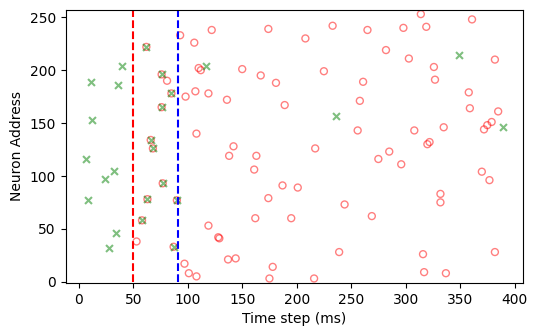

In [4]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'p_flip_target_init', fig_width=opt.fig_width, fig_height=opt.fig_height)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

Saving as ../figures/p_flip_target.pdf
Saving as ../figures/p_flip_target.png
Saving as ../figures/p_flip_target.svg


(torch.Size([16, 1024, 1100]), 1025.0, 1069.0)

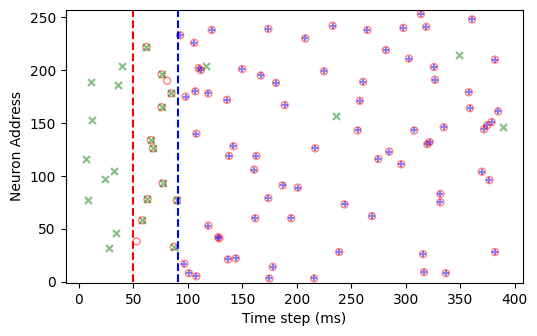

In [5]:
fig,ax = plt.subplots(figsize=(13, 8))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'p_flip_target', fig_width=opt.fig_width, fig_height=opt.fig_height)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

In [ ]:
def get_scores_noise(N_scan=opt.N_scan):
    p_noise = np.linspace(0, 1, N_scan, endpoint=True)
    scores_np = np.zeros(N_scan)
    for i_scan in trange(N_scan):
        with torch.no_grad():
            input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay)
            input_spikes = flip_bits(input_spikes, p_noise[i_scan])
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_evoked = hd.target[:, :, hd.opt.num_delay:]

            scores_np[i_scan] = get_f1score(spikes_evoked, target_evoked)

    return p_noise, scores_np

npy_filename = Path(data_cache) / f"{hd.opt.datetag}_noise.npz"
lock_filename = Path(data_cache) / f"{hd.opt.datetag}_noise.lock"
if RECOMPUTE:
    npy_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    data = np.load(npy_filename)
    p_noise = data['p_noise']
    scores_np = data['scores_np']
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Score weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Score file not found: {model_filename}, evaluating athe score.")
        lock_filename.touch(exist_ok=True)
        ##################
        p_noise, scores_np = get_scores_noise()
        ##################        
        np.savez(npy_filename, p_noise=p_noise, scores_np=scores_np)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Score file is locked: {lock_filename}, passing.")


Score weights loaded from ../cached_data/2026-04-21.pth


In [7]:
np.load(npy_filename).values()

ValuesView(NpzFile '../cached_data/2026-04-21_noise.npz' with keys: p_noise, scores_np)

In [8]:
p_noise, scores_np = np.load(npy_filename).values()

Saving as ../figures/p_flip_score.pdf
Saving as ../figures/p_flip_score.png
Saving as ../figures/p_flip_score.svg


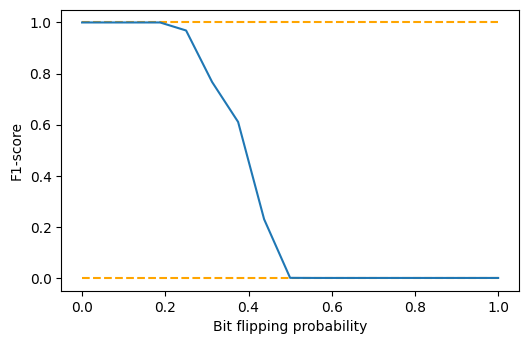

In [9]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hlines([0, 1], p_noise[0], p_noise[-1], 'orange', ls='--')
ax.plot(p_noise, scores_np)
ax.set_xlabel("Bit flipping probability")
ax.set_ylabel("F1-score")

if figpath is not None: 
    printfig(fig, 'p_flip_score', fig_width=opt.fig_width, fig_height=opt.fig_width/phi)